In [1]:
from beir.datasets.data_loader import GenericDataLoader
from beir import util
import pandas as pd
from preparation_utils import convert_beir_dbpedia_entity_v2_to_df
import matplotlib.pyplot as plt

c:\Users\marvi\.conda\envs\masterthesis\Lib\site-packages\beir\datasets\data_loader.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
dataset = "dbpedia-entity"
url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{}.zip".format(dataset)
data_path = util.download_and_unzip(url, "../03_data/raw_data/beir_dbpedia")
corpus, queries, qrels = GenericDataLoader(data_folder="../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

  0%|          | 0/4635922 [00:00<?, ?it/s]

In [3]:
corp = convert_beir_dbpedia_entity_v2_to_df(corpus)

In [4]:
# Mean Abstract Length
print("Mean:",corp["text"].str.len().mean())
print("Max: ",corp["text"].str.len().max())
print("Min: ",corp["text"].str.len().min())

Mean: 289.427268373915
Max:  42891
Min:  1


In [5]:
word_series  = corp["text"].str.split().str.len()

In [6]:
print("Mean:",word_series.mean())
print("Max: ",word_series.max())
print("Min: ",word_series.min())

Mean: 46.890764508447084
Max:  5227
Min:  1


In [7]:
len(corp[word_series>200])

1834

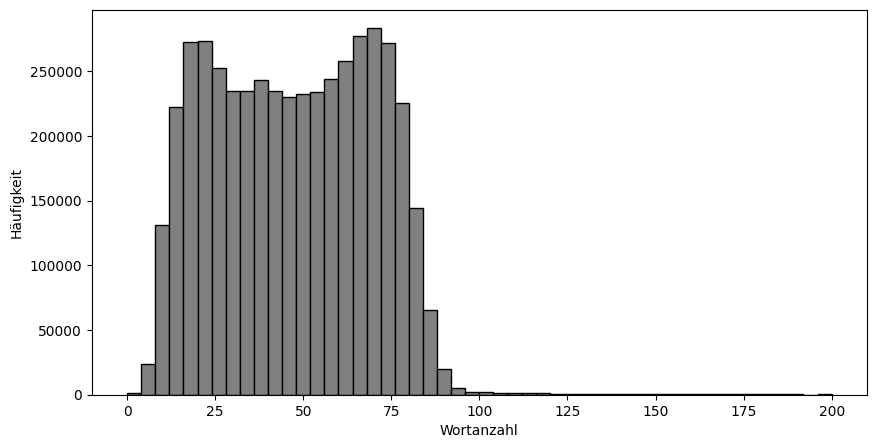

In [9]:
# Abbildung 9
plt.figure(figsize=(10, 5));
plt.hist(word_series, bins=50, range=[0, 200], color='grey', edgecolor='black');
plt.xlabel('Wortanzahl');
plt.ylabel('Häufigkeit');
plt.savefig("../05_results/Abbildung_9.svg")

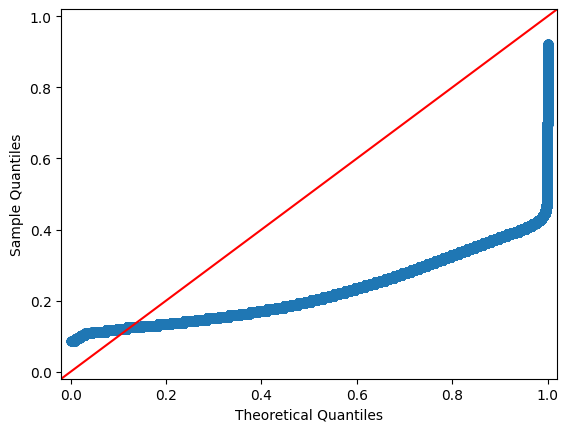

In [11]:
import scipy.stats as stats
import statsmodels.api as sm
import pylab

sm.qqplot(word_series[word_series<200], line='45',dist=stats.trapezoid, fit=True)
pylab.show()

In [13]:
corp[corp["text"].str.len()==42891]

,id,text,title
1912338,<dbpedia:Agrilus>,"Agrilus is a genus of jewel beetles, notable f...",Agrilus


In [16]:
corpus["<dbpedia:Agrilus>"]

{'text': 'Agrilus is a genus of jewel beetles, notable for having the largest number of species (about 3000) of any single genus in the animal kingdom.Species: Agrilus abantiades Descarpentries & Villiers, 1963 Agrilus abditus Horn, 1891 Agrilus abdominalis Saunders, 1874 Agrilus abductus Horn, 1891 Agrilus abeillei (Théry, 1905) Agrilus aberlenci Curletti, 1997 Agrilus aberrans Kerremans, 1900 Agrilus abhayi Baudon, 1965 Agrilus abjectus Horn, 1891 Agrilus abodimanganus Obenberger, 1931 Agrilus aborigines Curletti, 2001 Agrilus abramii Curletti & Dutto, 1999 Agrilus absonus Théry, 1934 Agrilus abstersus Horn, 1891 Agrilus abyssiniae Obenberger, 1935 Agrilus abyssinicus Obenberger, 1917 Agrilus acaciae Fisher, 1928 Agrilus acanthopterus Harold, 1869 Agrilus acastus Kerremans, 1913 Agrilus acceptus Waterhouse, 1889 Agrilus acclivis Waterhouse, 1889 Agrilus acer Curletti, 2006 Agrilus achardi Obenberger, 1935 Agrilus achepei Curletti, 2002 Agrilus achilleus Obenberger, 1935 Agrilus acolo